# Stream fitting

### Dimitra Giantsidi & Nolan Ottele 2026

This code measures the length and average width of a detected stream of a galaxy at different angles. It requires the matched-filter detection and the Segment outputs of the galaxy. It also calculates the length-to-width ratio vs. declination of observation. "Object of interest" refers to the stream throughout the code.

In [102]:
# import all necessary libraries
from pathlib import Path as path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import re
import math
import os
import copy
import matplotlib as mpl

In [258]:
# enter the name of the galaxy, its matchef-filter resolution, and desired number of angles
box = 'storm'
gal_num = '2'
galaxy_name = f'{box}_{gal_num}'
numpix=8000
numangles=24

In [259]:
# define the necessary file paths to get the data from
sd_outputs_path = (f'/home/giantsid/MAP/substructure_detection/sd_outputs')
segmented_path = path(f'{sd_outputs_path}/Segment/{galaxy_name}/segmented')
centers_path = path(f'{sd_outputs_path}/twod_exp_fit/{galaxy_name}/centers.txt')
mf_catalogs_path = path(f'/home/giantsid/MAP/matched_filter/mf_data/mf_catalogs/26_2000/{galaxy_name}/')

In [260]:
# define necessary values to be updated
area_of_interest = np.zeros((numangles, 89, 89), dtype=bool) # hardcoded for the number of angles
min_obj = 0
max_obj = 0
my_extent = [-60,60,-60,60]

In [261]:
def centers(file_name, galaxy_name):
    """Identifies the center of the galaxy at a specific angle.
    
    Requires the 2D exponential fit algorithm to have run first and for the existence of the centers path with the centers file
    formatted exactly as defined in the 2D exponential fit algorithm. It reads the declination and azimuth of the file_name, finds
    their match in the file and their respective x- and y- coordinates.
    
    Args:
        file_name (f string):
            The name of the file of the galaxy of interest of which the first two instances of numbers 
            should be the declination and the azimuth of observation in this order (separation by period is acceptable).
        galaxy_name (f string):
            The name of the galaxy of interest.

    Returns:
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
    """
    
    x_center = 0
    y_center = 0
    numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', file_name)]
    angles = numbers[1:-1]
    d = angles[0]
    a = angles[1]
    target_message = 'center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}'
    
    with open(f'{centers_path}', 'r') as file:
        for line in file:
            if target_message in line: # assumes there is only one instance of the correct message
                parts = line.strip().split(':')
                coords = parts[1].split(',')
                x_center = float(coords[0].strip())
                y_center = float(coords[1].strip())
                
    return x_center, y_center

In [262]:
def area_of_interest_finder(image_data):
    """ Identifies and isolates the largest area of a galaxy by its Segment output.

        This function automatically updates the predefined areas_of_interest array with 

    Args:
        image_data (hdul.data):
            The extracted data of a Segmented galaxy (from a .fits format).

    Returns:
        image_data (hdul.data):
            The modified image data to only include the background and the area of interest
        interest_obj (float):
            The (meaningless) value assigned by Segment to the objects of interest.
        
    """
    
    # identify the largest object
    objects, counts = np.unique(image_data, return_counts=True)
    
    # ... excluding background
    not_bg_mask = objects != 0
    objects = objects[not_bg_mask]
    counts = counts[not_bg_mask]
    
    # ... and excluding nan
    nan_index = np.where(np.isnan(objects))[0][0]
    wout_nan_objects = np.delete(objects, nan_index)
    wout_nan_counts = np.delete(counts, nan_index)
    i_max = np.argmax(wout_nan_counts)

    # remove all objects except the largest
    non_largest_mask = image_data != objects[i_max]
    image_data[non_largest_mask] = 0
    interest_obj = objects[i_max]

    # to mask the area of the matched filter
    area_of_interest[current_rotation, :, :] = image_data == interest_obj

    return image_data, interest_obj

In [263]:
def radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest):
    """ Calculates the density-weighted average radius of the area of interest within each given bin.

    Args:
        n_of_interest (int):
            Number of pixels of interest.
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_of_interest (empty array):
            To be filled with the x-coordinates of the pixels of interest.
        y_of_interest (empty array):
            To be filled with the y-coordinates of the pixels of interest.

    Returns:
        avg_radii (array of floats):
            Array of length equal to n_bins containing the average radius of the object of interest within each bin.
    """
    
    x_delta = [n - x_center for n in x_of_interest]
    y_delta = [n - y_center for n in y_of_interest]

    theta = [0] * n_of_interest

    for i in range(len(x_delta)):
        theta[i] = np.mod(math.atan2(y_delta[i],x_delta[i]), 2*np.pi)

    bin_size = 2*np.pi/n_bins

    ang_bin = [0] * n_of_interest
    for i in range(len(theta)):
        ang_bin[i] = int(np.floor(theta[i]/bin_size))

    radii = [0] * n_of_interest
    for i in range(n_of_interest):
        radii[i] = np.sqrt(x_delta[i]**2 + y_delta[i]**2)

    avg_radii = [0] * n_bins

    for j in range(n_bins):
        radii_sum = 0
        radii_counter = 0
        for i in range(len(ang_bin)):
            if ang_bin[i] == j:
                radii_sum = radii_sum + radii[i]
                radii_counter = radii_counter + 1
        if radii_counter == 0:
            radii_average = 0
        else:
            radii_average = radii_sum / radii_counter
        avg_radii[j] = radii_average
    avg_radii = np.array(avg_radii)

    return avg_radii

In [264]:
current_rotation = 0

# Isolate the area of interest, split it into angular bins and calculate its density-weighted average radius within each bin
for file in sorted(segmented_path.iterdir()):
    if file.is_file():

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]

        # load the segmented fits file
        hdul = fits.open(f'{segmented_path}/{file.name}')
        image_data = hdul[3].data # 3 is the index of isolated objects

        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)

        # plot the bins (only for visual aid purposes)
        n_bins = 32
        
        # find area of interest
        image_data, interest_obj = area_of_interest_finder(image_data)

        x_of_interest = []
        y_of_interest = []

        # find data of interest (non-background and of largest object)
        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if val == interest_obj:
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)

        # number of pixels of interest
        n_of_interest = len(x_of_interest)

        # calculate the average readius of each bin
        avg_radii = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)
        
        current_rotation = current_rotation + 1

In [265]:
def find_large_outliers(data, multiplier=1.5):
    """Finds only large, extreme upper outliers while ignoring NaNs and small values.

    Args:
        data (array of numbers):
            The desired data to be checked for large outliers.

    Returns:
        outlier_values (number or array of numbers):
            The numbers identified as large outliers.
    """
    data = np.array(data)
    
    # Calculate upper quartile parameters ignoring NaN
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    
    # Establish a high upper fence
    upper_bound = q3 + (multiplier * iqr)
    
    # Extract only values exceeding this high threshold
    outlier_indices = np.where(data > upper_bound)
    outlier_values = data[outlier_indices]
    
    return outlier_values

In [266]:
def ray_cells_in_grid(x0, y0, dx, dy, width, height):
    """ Amanatides-Woo traversal algorithm. Copied from the internet. Calculates the grid pixels a line goes through.
        Basic idea is to calculate parametrically which edge of the box a line is approaching at any given time.

    Args:
        x0: Starting x value in grid coordinates

        y0: Starting y value in grid coordinates

        dx: Change in x with respect to time. Really just numerator of slope.

        dy: Change in y with respect to time. Really just denominator of slope.

        width: X size of the grid.

        height: Y size of the grid

    Returns:
        cells (): A list of cells the line goes through, including the first cell it starts in. 
            
    """
    if dx == 0 and dy == 0:
        raise ValueError("direction vector (dx, dy) cannot be (0, 0)")
 
    i, j = math.floor(x0), math.floor(y0)
    if not (0 <= i < width and 0 <= j < height):
        return []
    cells = [(x0,y0),(i, j)] 
 
    step_i = 1 if dx > 0 else (-1 if dx < 0 else 0)
    step_j = 1 if dy > 0 else (-1 if dy < 0 else 0)
 
    # tMaxX/tMaxY: parametric distance to the next vertical/horizontal
    # grid line. tDeltaX/tDeltaY: how much that increases per cell.
    if dx != 0:
        next_x = i + (1 if dx > 0 else 0)
        tMaxX = (next_x - x0) / dx
        tDeltaX = abs(1.0 / dx)
    else:
        tMaxX = math.inf
        tDeltaX = math.inf
 
    if dy != 0:
        next_y = j + (1 if dy > 0 else 0)
        tMaxY = (next_y - y0) / dy
        tDeltaY = abs(1.0 / dy)
    else:
        tMaxY = math.inf
        tDeltaY = math.inf
 
    while True:
        if tMaxX < tMaxY:
            tMaxX += tDeltaX
            i += step_i
        elif tMaxY < tMaxX:
            tMaxY += tDeltaY
            j += step_j
        else:
            tMaxX += tDeltaX
            tMaxY += tDeltaY
            i += step_i
            j += step_j
 
        if not (0 <= i < width and 0 <= j < height):
            break
        cells.append((i, j))
        if len(cells)>=11:
            break
 
    return cells

In [267]:
def length_calc(n_bins, x_center, y_center, x_ang, y_ang):
    """ Calculates the total length of the stream.

    Args:
        n_bins (int):
            Number of bins.
        x_center (float):
            The x-coordinate of the center of the galaxy.
        y_center (float):
            The y-coordinate of the center of the galaxy.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        total_dist (float):
            The total calculated length of the stream.
    """

    total_dist = 0
    
    for i in range(n_bins):
        
        # calculate the separation between a pair of points
        p1 = i
        p2 = np.mod(i+1, n_bins) #Enables looping from final bin to first bin
        
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]

        dist = 0
        
        if (x_ang[p1] != x_center or y_ang[p1] != y_center) and (x_ang[p2] != x_center or y_ang[p2] != y_center): 
            dist = np.sqrt(x_sep**2 + y_sep**2) #Distance for this specific pair
            total_dist = total_dist + dist  #Total accumulated distance

            plt.plot([x_ang[p1], x_ang[p2]], [y_ang[p1], y_ang[p2]], color = '#72BCD4', alpha=0.5) #Line from point 1 to point 2

    return total_dist

In [268]:
def width_calc(image_data, n_bins, x_ang, y_ang):
    """ Calculates the width of bins of the stream.

    Args:
        image_data (hdul.data):
            The extracted data of a matched-filtered galaxy (from a .fits format).
        n_bins (int):
            Number of bins.
        x_ang (array of floats):
            The x-coordinates of the angular midpoints of the bins at the average radius.
        y_ang (array of floats):
            The y-coordinates of the angular midpoints of the bins at the average radius.

    Returns:
        stream_width_counter (int):
            The number of widths calculated.
        stream_width_total (float):
            The sum of the widths calculated.
    """

    stream_width = 0
    stream_width_counter = 0
    stream_width_total = 0

    for i in range(n_bins):
    
        p1 = i
        p2 = np.mod(i+1, n_bins) # enables looping from final bin to first bin
    
        x_mid = (x_ang[p1]+x_ang[p2])/2
        y_mid = (y_ang[p1]+y_ang[p2])/2
        #plt.scatter(x_mid, y_mid, color = 'green', s=20) # plots midpoints between any two given points
    
        x_mid_as_grid = round((60+x_mid)*89/120) # converts midpoints into grid coordinates
        y_mid_as_grid = 89-round((60+y_mid)*89/120)
    
        # calculate the separation between a pair of points
        x_sep = x_ang[p1]-x_ang[p2]
        y_sep = y_ang[p1]-y_ang[p2]
    
        if x_sep == 0 and y_sep == 0: 
            print(f"{i}. Invalid. No separation.") # prevents crashing in case of non-existing average radius/radii
            
        else:
            cells_1 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, y_sep, x_sep, 89, 89) # lists all cells in line in one direction from muidpoing
            cells_2 = ray_cells_in_grid(x_mid_as_grid, y_mid_as_grid, -y_sep, -x_sep, 89, 89) # lists all cells in opposite direction
    
            accept_limit = 4 # limit for consecutive nan encounters. WE STRONGLY ADVISE TO ADJUST FOR EACH GALAXY
    
            # identify stopping points due to nan encounters in both directions
            limit_1 = 0
            for n in range(len(cells_1)):
                if np.isnan(image_data[cells_1[n][1]][cells_1[n][0]]):
                    break_counter = 0
                    for m in range(accept_limit):
                        if n+m <= len(cells_1):
                            if np.isnan(image_data[cells_1[n+m-1][1]][cells_1[n+m-1][0]]):
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_1 = n
                    if break_counter == accept_limit:
                        break
                limit_1 = n
    
            limit_2 = 0
            for n in range(len(cells_2)):
                if np.isnan(image_data[cells_2[n][1]][cells_2[n][0]]):
                    break_counter = 0
                    for m in range(accept_limit):
                        if n+m <= len(cells_2):
                            if np.isnan(image_data[cells_2[n+m-1][1]][cells_2[n+m-1][0]]):
                                break_counter = break_counter + 1
                            else:
                                break
                        else:
                            break
                    limit_2 = n
                    if break_counter == accept_limit:
                        break
                limit_2 = n
    
            # apply stoppoing points in both directions
            cells_1_culled = [[x, y] for x, y in cells_1[:limit_1] if not np.isnan(image_data[y][x])]
            cells_2_culled = [[x, y] for x, y in cells_2[:limit_2] if not np.isnan(image_data[y][x])]
    
            if len(cells_1_culled)!=0 and len(cells_2_culled)!=0: # case where the area extends in both directions
                
                cell_first = cells_1_culled[-1] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)==0 and len(cells_2_culled)!=0: # case where the area does not extend in one direction
    
                cell_first = cells_2_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_2_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordinates of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
    
            elif len(cells_1_culled)!=0 and len(cells_2_culled)==0: # case where the area does not extend in the other direction
    
                cell_first = cells_1_culled[0] # selects the farthest cell from the culled population
                cell_last = cells_1_culled[-1]
    
                cell_first_x_coord = (-60 + (cell_first[0] * (120 / 89))) + 60/89  # coordintes of centers of endpoint cells in image coordinates
                cell_last_x_coord = (-60 + (cell_last[0] * (120 / 89))) +60/89
    
                cell_first_y_coord = (-60 + (-(cell_first[1]-89) * (120 / 89))) -60/89 
                cell_last_y_coord = (-60 + (-(cell_last[1]-89) * (120 / 89))) -60/89 
    
                plt.plot([cell_first_x_coord, cell_last_x_coord], [cell_first_y_coord, cell_last_y_coord], color = 'teal') # plots line connecting endpoints
                stream_width = np.sqrt((cell_first_x_coord - cell_last_x_coord)**2 + (cell_first_y_coord - cell_last_y_coord)**2)
                
                print(f"{i} Width: {stream_width}. Distance: {dist}")
    
                stream_width_counter = stream_width_counter + 1
                stream_width_total = stream_width_total + stream_width
                
            else: # case where the area does not extend in either direction
                 print(f"{i}. Invalid. No width.")

    return stream_width_counter, stream_width_total

In [269]:
# define necessary values to be updated
ratio = 0
length_array = []
width_array = []
ratio_array = []

mf_storm_2_d=0.0_a=0.0_pix=8000.fits
0 Width: 4.263745159777589. Distance: 2.473793930368742
1 Width: 4.263745159777589. Distance: 2.473793930368742
2 Width: 4.263745159777589. Distance: 2.473793930368742
3 Width: 3.0149231157300567. Distance: 2.473793930368742
4 Width: 9.044769347190154. Distance: 2.473793930368742
5 Width: 10.268458120265946. Distance: 2.473793930368742
6 Width: 6.875082490237462. Distance: 2.473793930368742
7 Width: 9.534024015998392. Distance: 2.473793930368742
8 Width: 6.875082490237463. Distance: 2.473793930368742
9. Invalid. No width.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No

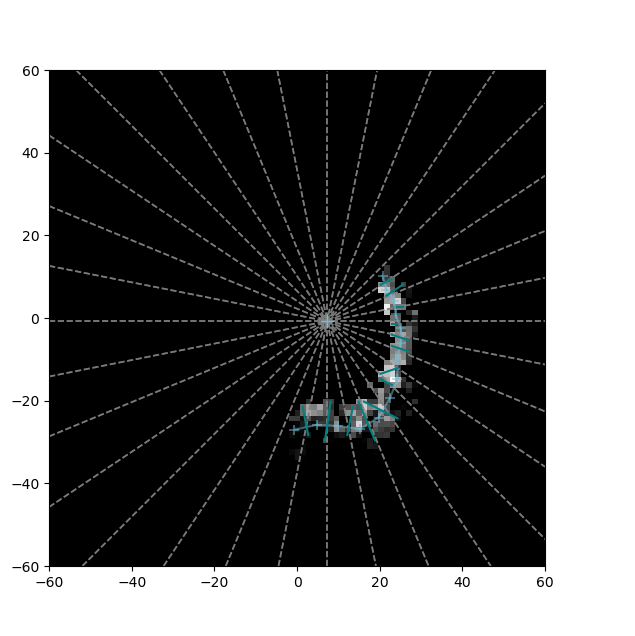

mf_storm_2_d=17.0_a=222.5_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No width.
13 Width: 6.875082490237462. Distance: 2.473793930368742
14 Width: 7.861957611027375. Distance: 2.473793930368742
15 Width: 6.029846231460107. Distance: 2.473793930368742
16 Width: 1.3483146067415746. Distance: 2.473793930368742
17 Width: 6.875082490237457. Distance: 2.473793930368742
18 Width: 11.118487080317285. Distance: 2.473793930368742
19 Width: 11.598640809495674. Distance: 2.473793930368742
20 Width: 4.861417450063805. Distance: 2.473793930368742
21 Width: 1.3483146067415674. Distance: 2.473793930368742
22. Invalid. No width.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No

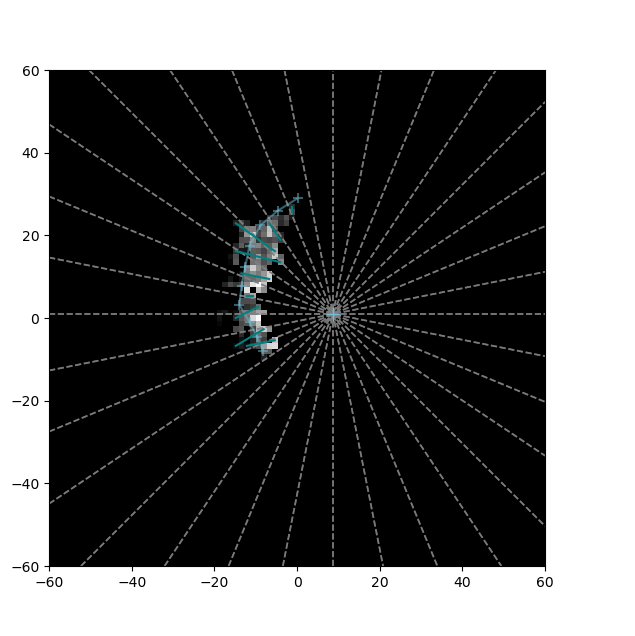

mf_storm_2_d=24.1_a=85.0_pix=8000.fits
0 Width: 0.0. Distance: 2.473793930368742
1 Width: 7.861957611027367. Distance: 2.473793930368742
2 Width: 4.044943820224727. Distance: 2.473793930368742
3 Width: 2.696629213483149. Distance: 2.473793930368742
4 Width: 6.741573033707863. Distance: 2.473793930368742
5 Width: 7.861957611027367. Distance: 2.473793930368742
6. Invalid. No width.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No width.
19. Invalid. No width.
20 Width: 4.263745159777589. Distance: 2.473793930368742
21 Width: 1.3483146067415674. Distance: 2.473793930368742
22 Width: 3.8136096063993565. Distance: 2.473793930368742
23 Width: 6.029846231460114. Distance: 2.473793930368742
24. Invalid. No width.
25 Width: 5.5

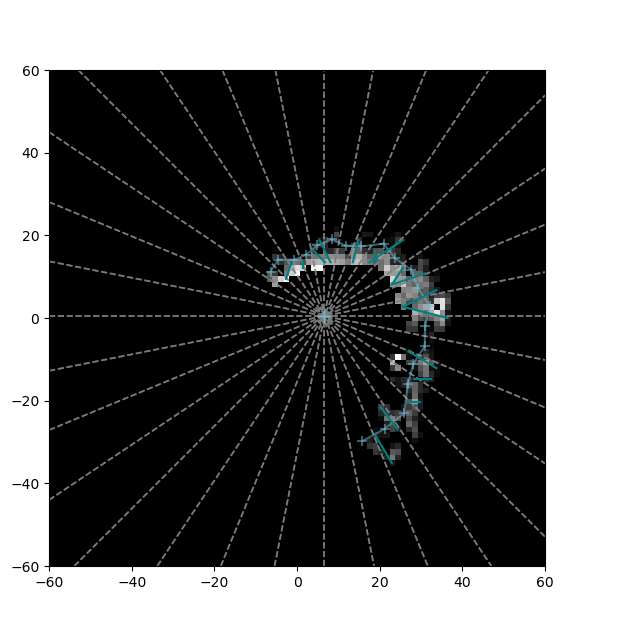

mf_storm_2_d=29.6_a=307.5_pix=8000.fits
0 Width: 0.0. Distance: 2.473793930368742
1. Invalid. No width.
2 Width: 1.3483146067415817. Distance: 2.473793930368742
3 Width: 8.201477568941415. Distance: 2.473793930368742
4 Width: 0.0. Distance: 2.473793930368742
5 Width: 6.875082490237464. Distance: 2.473793930368742
6 Width: 7.86195761102737. Distance: 2.473793930368742
7 Width: 11.520005049866333. Distance: 2.473793930368742
8 Width: 8.633425938111706. Distance: 2.473793930368742
9 Width: 7.2608963691701165. Distance: 2.473793930368742
10 Width: 3.8136096063993565. Distance: 2.473793930368742
11 Width: 4.263745159777595. Distance: 2.473793930368742
12 Width: 6.029846231460107. Distance: 2.473793930368742
13 Width: 10.268458120265946. Distance: 2.473793930368742
14. Invalid. No width.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid

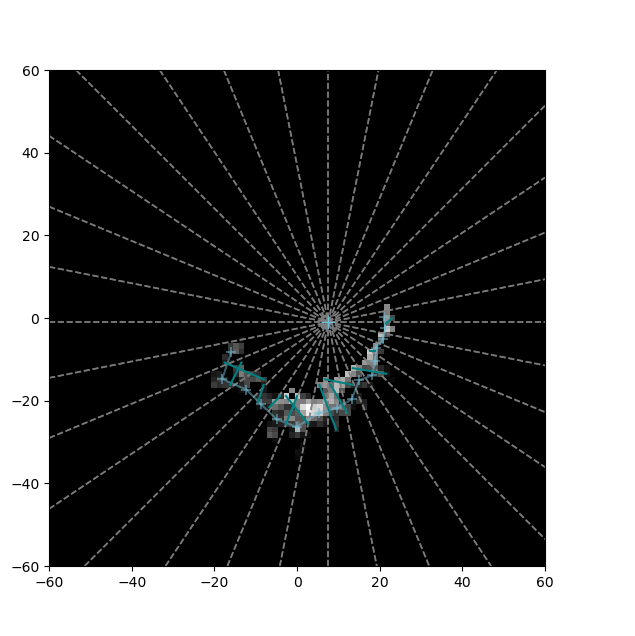

mf_storm_2_d=34.3_a=170.0_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No width.
15 Width: 3.0149231157300567. Distance: 2.473793930368742
16 Width: 7.6272192127987175. Distance: 2.473793930368742
17 Width: 8.20147756894142. Distance: 2.473793930368742
18 Width: 5.720414409599032. Distance: 2.473793930368742
19 Width: 6.029846231460113. Distance: 2.473793930368742
20 Width: 4.263745159777589. Distance: 2.473793930368742
21 Width: 4.861417450063811. Distance: 2.473793930368742
22 Width: 7.86195761102737. Distance: 2.473793930368742
23 Width: 5.559243540158638. Distance: 2.473793930368742
24 Width: 4.26374515977759. Distance: 2.47

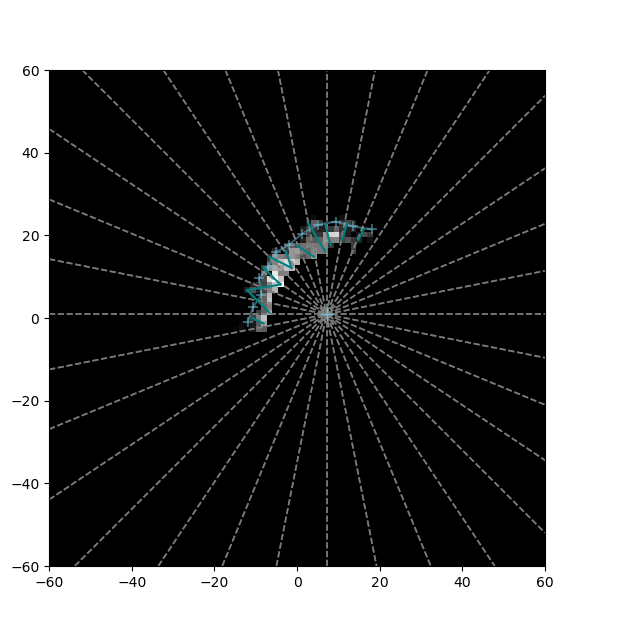

mf_storm_2_d=38.5_a=32.5_pix=8000.fits
0 Width: 3.0149231157300442. Distance: 2.473793930368742
1 Width: 8.201477568941414. Distance: 2.473793930368742
2 Width: 10.268458120265946. Distance: 2.473793930368742
3 Width: 8.201477568941415. Distance: 2.473793930368742
4 Width: 4.861417450063811. Distance: 2.473793930368742
5. Invalid. No width.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No width.
22 Width: 0.0. Distance: 2.473793930368742
23 Width: 1.9068048031996807. Distance: 2.473793930368742
24 Width: 1.3483146067415817. Distance: 2.473793930368742
25 Width: 1.3483146067415817. Distance: 2.473793930368742
2

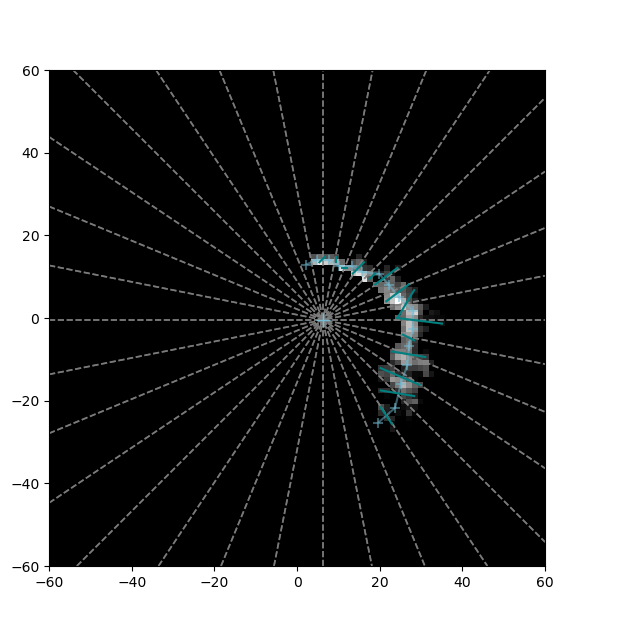

mf_storm_2_d=42.3_a=255.0_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No width.
11 Width: 3.0149231157300505. Distance: 2.473793930368742
12 Width: 7.861957611027364. Distance: 2.473793930368742
13 Width: 9.722834900127612. Distance: 2.473793930368742
14 Width: 11.520005049866334. Distance: 2.473793930368742
15 Width: 10.268458120265946. Distance: 2.473793930368742
16. Invalid. No width.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No sepa

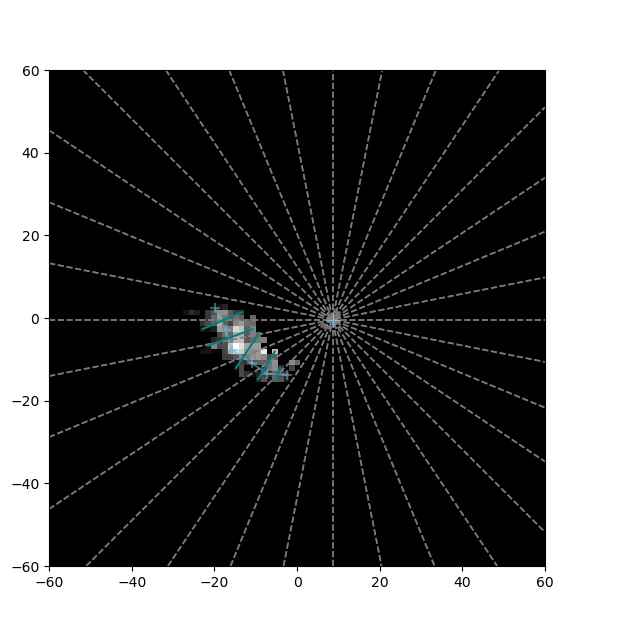

mf_storm_2_d=45.9_a=117.4_pix=8000.fits
0 Width: 4.263745159777598. Distance: 2.473793930368742
1 Width: 12.719974560076317. Distance: 2.473793930368742
2. Invalid. No width.
3. Invalid. No width.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No width.
25 Width: 0.0. Distance: 2.473793930368742
26 Width: 1.3483146067415674. Distance: 2.473793930368742
27 Width: 4.861417450063805. Distance: 2.473793930368742
28 Width: 8.633425938111701. Distance: 2.473793930368742
29 Width: 9

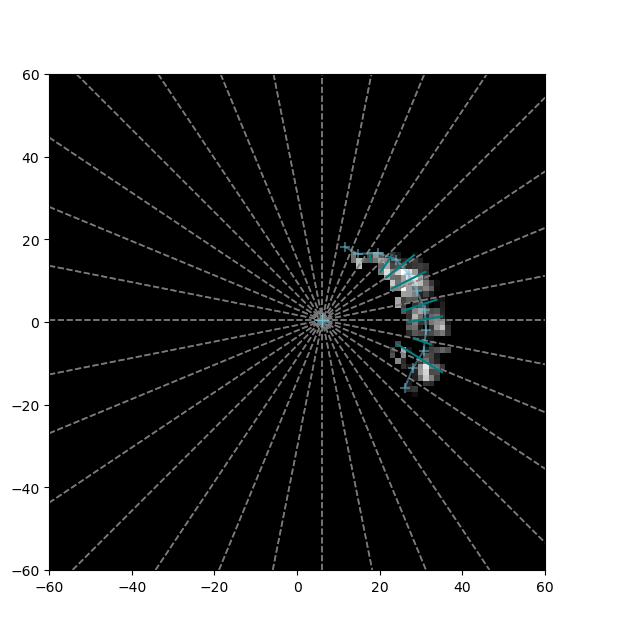

mf_storm_2_d=49.3_a=339.9_pix=8000.fits
0 Width: 4.263745159777589. Distance: 2.473793930368742
1 Width: 6.875082490237464. Distance: 2.473793930368742
2 Width: 6.741573033707857. Distance: 2.473793930368742
3 Width: 5.720414409599048. Distance: 2.473793930368742
4 Width: 4.861417450063802. Distance: 2.473793930368742
5 Width: 10.530673720323575. Distance: 2.473793930368742
6 Width: 10.530673720323582. Distance: 2.473793930368742
7 Width: 10.870459885346364. Distance: 2.473793930368742
8 Width: 6.029846231460107. Distance: 2.473793930368742
9. Invalid. No width.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid

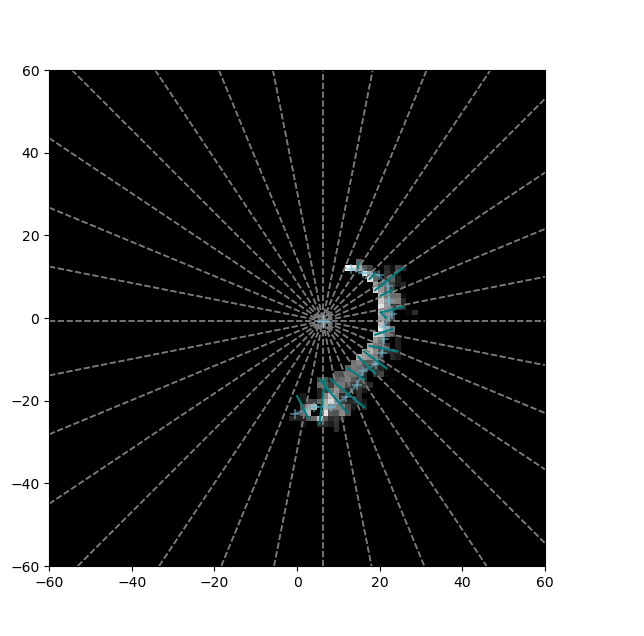

mf_storm_2_d=52.5_a=202.4_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No width.
15 Width: 5.559243540158643. Distance: 2.473793930368742
16 Width: 5.559243540158641. Distance: 2.473793930368742
17 Width: 7.260896369170114. Distance: 2.473793930368742
18 Width: 9.72283490012761. Distance: 2.473793930368742
19 Width: 4.263745159777589. Distance: 2.473793930368742
20 Width: 4.263745159777589. Distance: 2.473793930368742
21. Invalid. No width.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separat

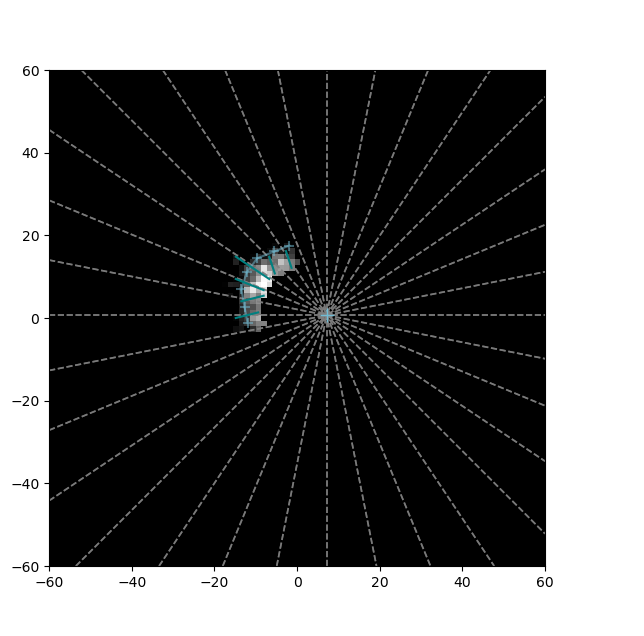

mf_storm_2_d=55.6_a=64.9_pix=8000.fits
0 Width: 10.268458120265946. Distance: 2.473793930368742
1 Width: 7.627219212798719. Distance: 2.473793930368742
2 Width: 8.633425938111696. Distance: 2.473793930368742
3 Width: 6.029846231460097. Distance: 2.473793930368742
4 Width: 1.906804803199686. Distance: 2.473793930368742
5 Width: 3.0149231157300536. Distance: 2.473793930368742
6 Width: 10.870459885346357. Distance: 2.473793930368742
7 Width: 6.875082490237462. Distance: 2.473793930368742
8 Width: 3.0149231157300505. Distance: 2.473793930368742
9. Invalid. No width.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid

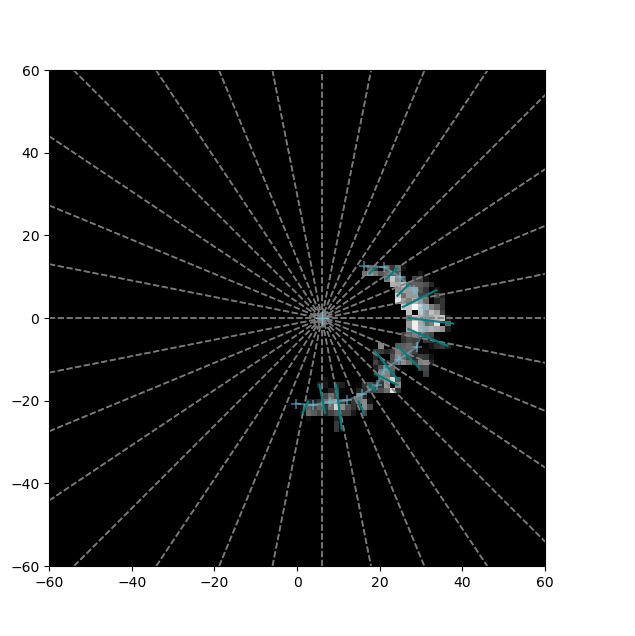

mf_storm_2_d=58.6_a=287.4_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No width.
7 Width: 6.0298462314601045. Distance: 2.473793930368742
8 Width: 1.3483146067415746. Distance: 2.473793930368742
9 Width: 8.527490319555175. Distance: 2.473793930368742
10 Width: 8.527490319555174. Distance: 2.473793930368742
11 Width: 10.268458120265942. Distance: 2.473793930368742
12 Width: 7.627219212798713. Distance: 2.473793930368742
13 Width: 6.875082490237463. Distance: 2.473793930368742
14 Width: 6.875082490237463. Distance: 2.473793930368742
15 Width: 12.209508051421237. Distance: 2.473793930368742
16. Invalid. No width.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No

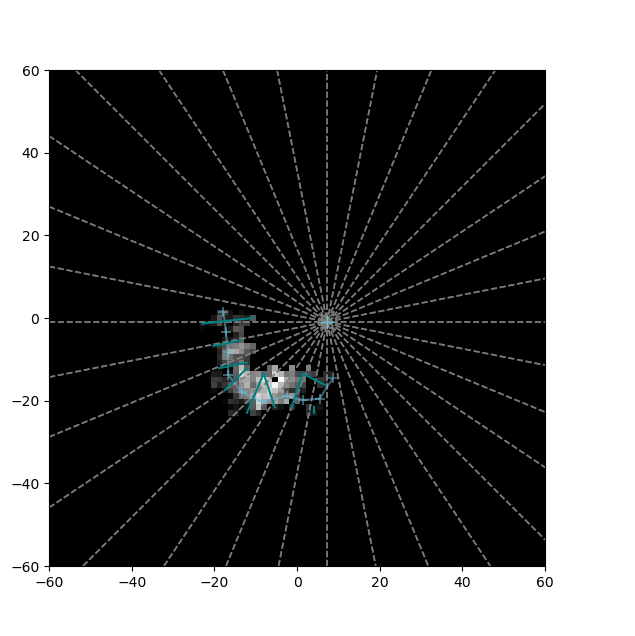

mf_storm_2_d=61.4_a=149.9_pix=8000.fits
0 Width: 11.118487080317285. Distance: 2.473793930368742
1. Invalid. No width.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No width.
29 Width: 8.633425938111701. Distance: 2.473793930368742
30 Width: 11.520005049866336. Distance: 2.473793930368742
31 Width: 21.6151274721

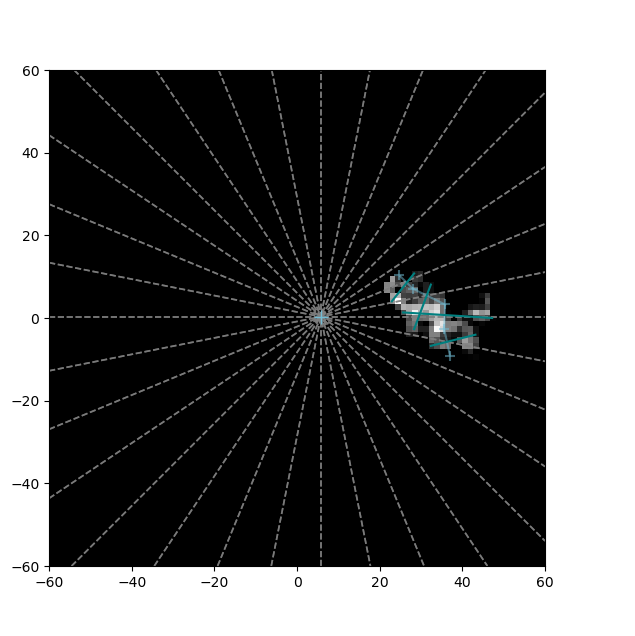

mf_storm_2_d=64.2_a=12.4_pix=8000.fits
0 Width: 6.741573033707874. Distance: 2.473793930368742
1 Width: 7.86195761102737. Distance: 2.473793930368742
2 Width: 7.627219212798719. Distance: 2.473793930368742
3 Width: 7.260896369170119. Distance: 2.473793930368742
4 Width: 4.263745159777586. Distance: 2.473793930368742
5 Width: 6.029846231460112. Distance: 2.473793930368742
6 Width: 10.26845812026594. Distance: 2.473793930368742
7 Width: 2.696629213483142. Distance: 2.473793930368742
8 Width: 1.9068048031996758. Distance: 2.473793930368742
9. Invalid. No width.
10 Width: 7.8619576110273695. Distance: 2.473793930368742
11 Width: 2.696629213483142. Distance: 2.473793930368742
12 Width: 4.861417450063807. Distance: 2.473793930368742
13. Invalid. No width.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No 

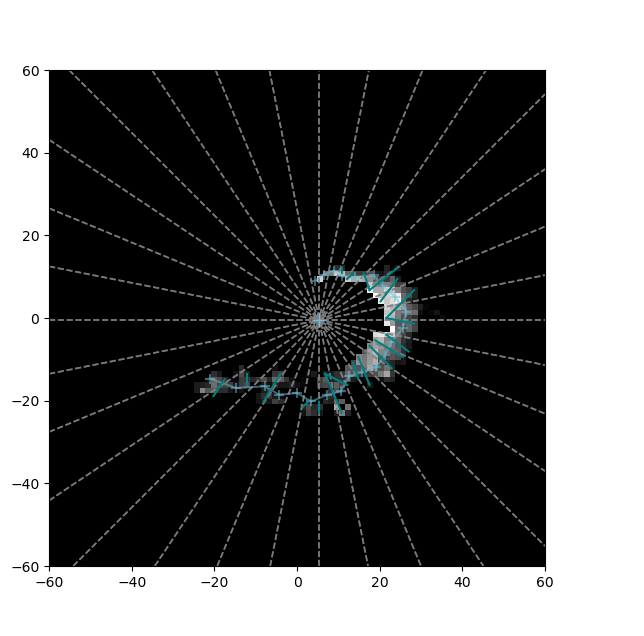

mf_storm_2_d=67.0_a=234.9_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No width.
13 Width: 4.263745159777596. Distance: 2.473793930368742
14 Width: 9.722834900127612. Distance: 2.473793930368742
15 Width: 10.870459885346357. Distance: 2.473793930368742
16 Width: 4.263745159777593. Distance: 2.473793930368742
17. Invalid. No width.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No separation.
30. Invalid. No separat

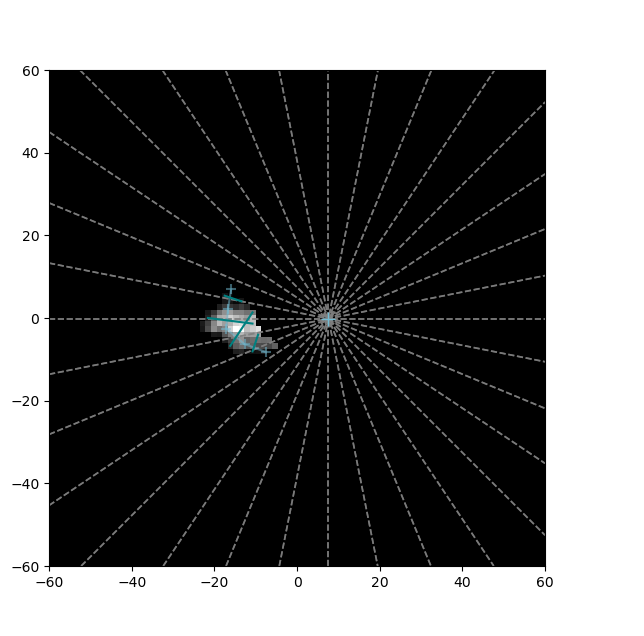

mf_storm_2_d=69.6_a=97.4_pix=8000.fits
0 Width: 12.719974560076317. Distance: 2.473793930368742
1 Width: 15.254438425597431. Distance: 2.473793930368742
2 Width: 0.0. Distance: 2.473793930368742
3. Invalid. No width.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No width.
28 Width: 7.260896369170118. Distance: 2.473793930368742
29 Width: 10.530673720323575. Distance: 2.473793930368742
30 Widt

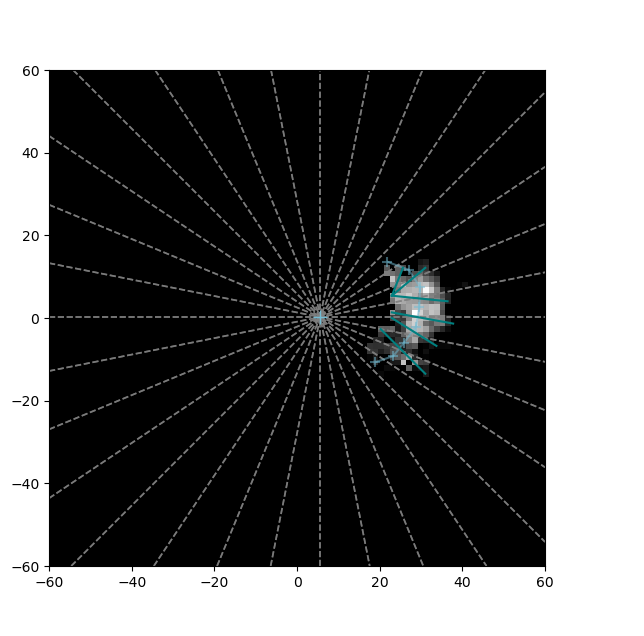

mf_storm_2_d=72.3_a=319.9_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No width.
5 Width: 1.9068048031996758. Distance: 2.473793930368742
6 Width: 4.263745159777593. Distance: 2.473793930368742
7 Width: 9.044769347190154. Distance: 2.473793930368742
8 Width: 2.696629213483142. Distance: 2.473793930368742
9 Width: 6.875082490237462. Distance: 2.473793930368742
10 Width: 9.53402401599839. Distance: 2.473793930368742
11 Width: 9.044769347190154. Distance: 2.473793930368742
12 Width: 12.43084645927131. Distance: 2.473793930368742
13 Width: 9.53402401599839. Distance: 2.473793930368742
14 Width: 0.0. Distance: 2.473793930368742
15. Invalid. No width.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. I

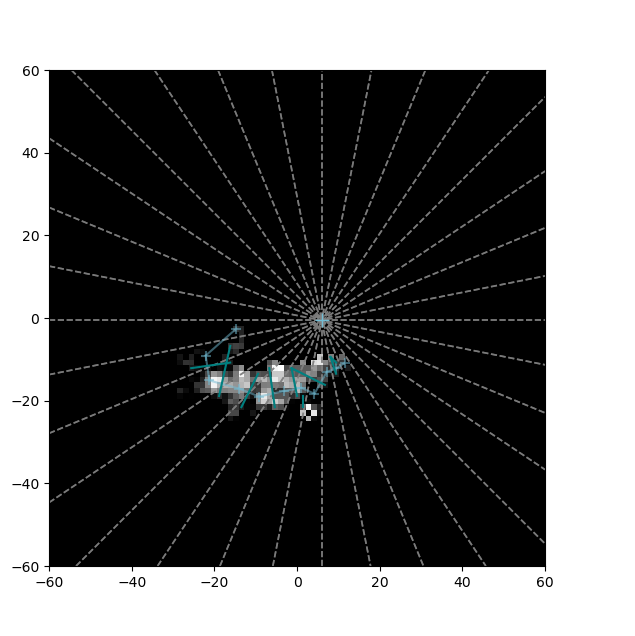

mf_storm_2_d=74.9_a=182.4_pix=8000.fits
0. Invalid. No width.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No width.
29 Width: 9.044769347190162. Distance: 2.473793930368742
30 Width: 16.67773062047592. Distance: 2.473793930368742
31 Width: 13.279358833882394. Distance: 2.473793930368

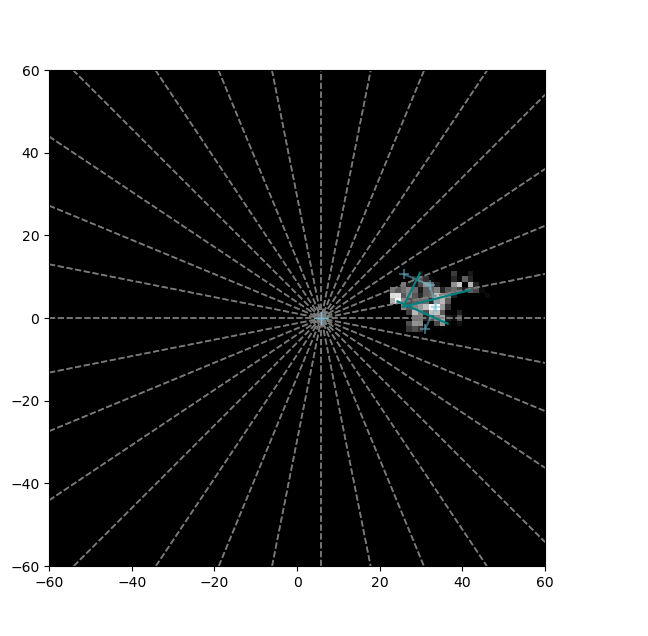

mf_storm_2_d=77.4_a=44.9_pix=8000.fits
0 Width: 8.63342593811171. Distance: 2.473793930368742
1 Width: 3.0149231157300536. Distance: 2.473793930368742
2 Width: 4.263745159777591. Distance: 2.473793930368742
3 Width: 1.9068048031996758. Distance: 2.473793930368742
4 Width: 6.029846231460107. Distance: 2.473793930368742
5 Width: 11.520005049866334. Distance: 2.473793930368742
6 Width: 6.0298462314601045. Distance: 2.473793930368742
7. Invalid. No width.
8. Invalid. No width.
9 Width: 0.0. Distance: 2.473793930368742
10 Width: 6.875082490237457. Distance: 2.473793930368742
11 Width: 7.627219212798713. Distance: 2.473793930368742
12 Width: 3.0149231157300465. Distance: 2.473793930368742
13 Width: 1.3483146067415746. Distance: 2.473793930368742
14. Invalid. No width.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23.

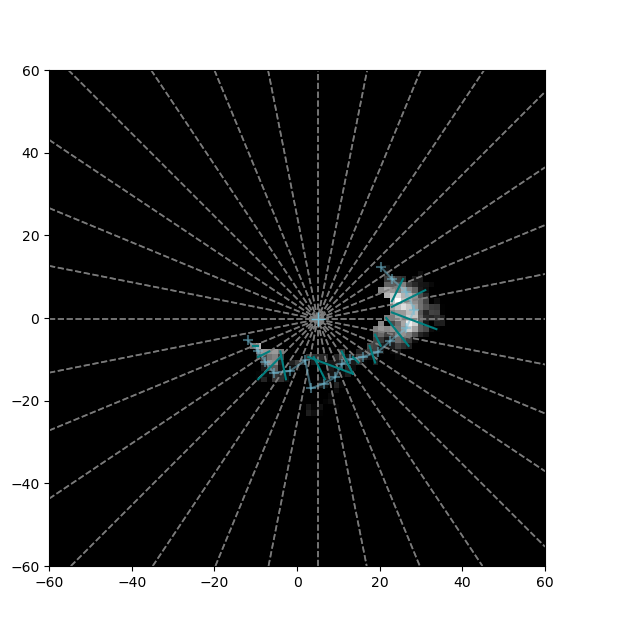

mf_storm_2_d=80.0_a=267.4_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No width.
11 Width: 6.875082490237462. Distance: 2.473793930368742
12 Width: 12.430846459271308. Distance: 2.473793930368742
13 Width: 13.550394095893337. Distance: 2.473793930368742
14 Width: 6.875082490237463. Distance: 2.473793930368742
15 Width: 1.3483146067415746. Distance: 2.473793930368742
16. Invalid. No width.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No sepa

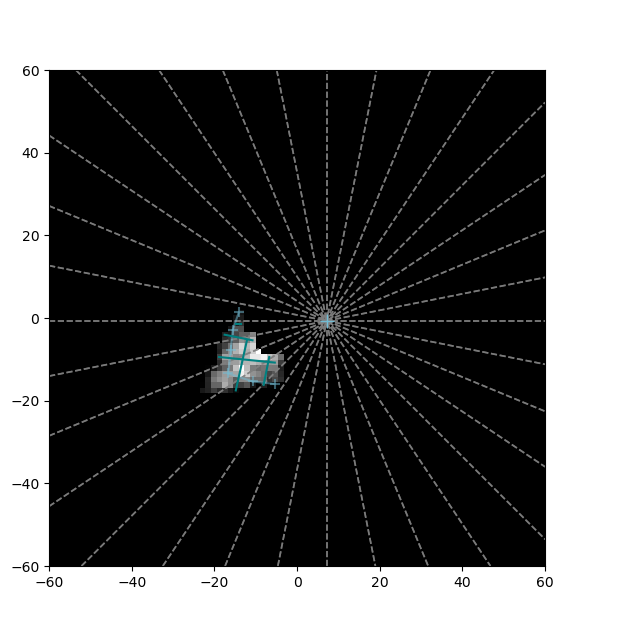

mf_storm_2_d=82.5_a=129.8_pix=8000.fits
0 Width: 8.201477568941415. Distance: 2.473793930368742
1. Invalid. No width.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No width.
29 Width: 9.044769347190162. Distance: 2.473793930368742
30 Width: 15.074615578650262. Distance: 2.473793930368742
31 Width: 15.07461557865

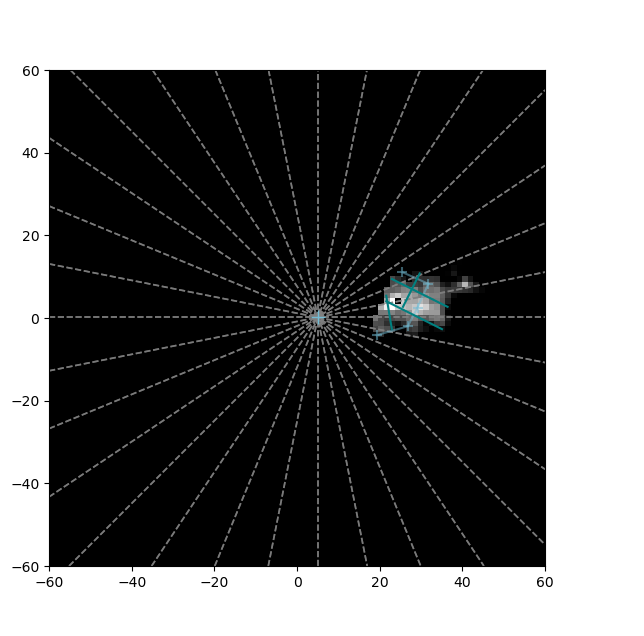

mf_storm_2_d=85.0_a=352.3_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No width.
11 Width: 4.263745159777589. Distance: 2.473793930368742
12 Width: 9.53402401599839. Distance: 2.473793930368742
13 Width: 10.268458120265942. Distance: 2.473793930368742
14. Invalid. No width.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No separation.
30. Invalid. No separation.
31. Invalid. No separatio

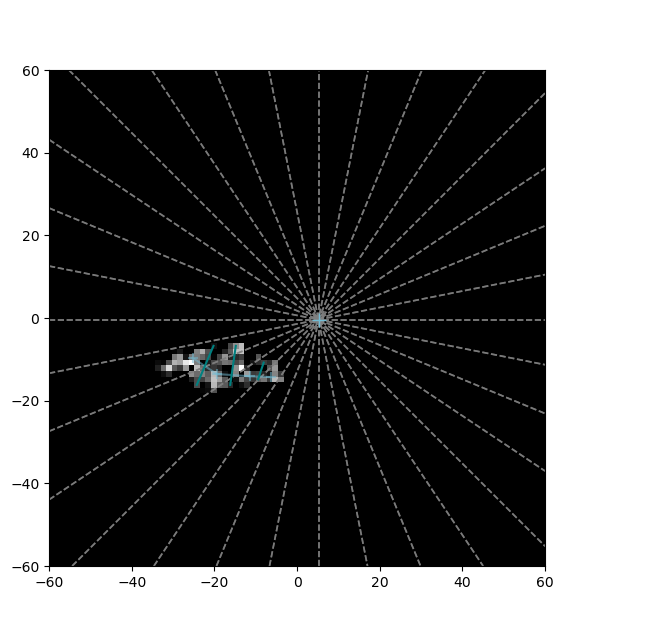

mf_storm_2_d=87.5_a=214.8_pix=8000.fits
0. Invalid. No separation.
1. Invalid. No separation.
2. Invalid. No separation.
3. Invalid. No separation.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No width.
11 Width: 6.029846231460104. Distance: 2.473793930368742
12 Width: 8.633425938111701. Distance: 2.473793930368742
13 Width: 9.044769347190162. Distance: 2.473793930368742
14 Width: 9.04476934719016. Distance: 2.473793930368742
15 Width: 1.3483146067415746. Distance: 2.473793930368742
16. Invalid. No width.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No separation.
29. Invalid. No separat

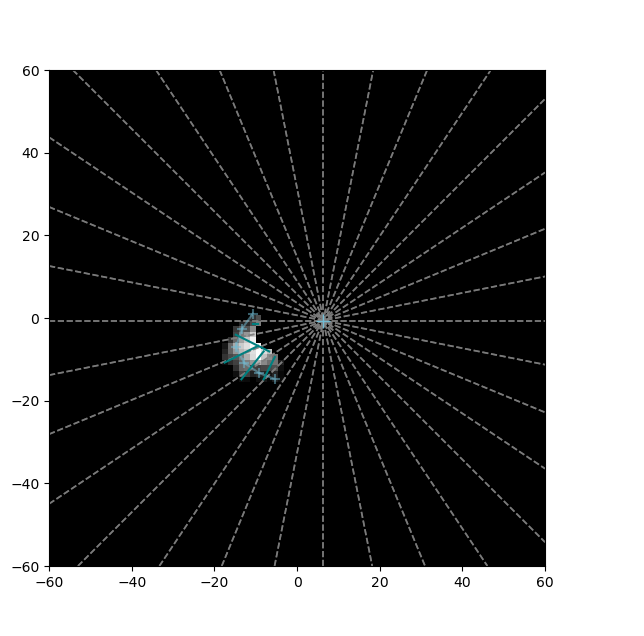

mf_storm_2_d=90.0_a=77.3_pix=8000.fits
0 Width: 6.741573033707871. Distance: 2.473793930368742
1 Width: 2.696629213483149. Distance: 2.473793930368742
2 Width: 1.9068048031996807. Distance: 2.473793930368742
3. Invalid. No width.
4. Invalid. No separation.
5. Invalid. No separation.
6. Invalid. No separation.
7. Invalid. No separation.
8. Invalid. No separation.
9. Invalid. No separation.
10. Invalid. No separation.
11. Invalid. No separation.
12. Invalid. No separation.
13. Invalid. No separation.
14. Invalid. No separation.
15. Invalid. No separation.
16. Invalid. No separation.
17. Invalid. No separation.
18. Invalid. No separation.
19. Invalid. No separation.
20. Invalid. No separation.
21. Invalid. No separation.
22. Invalid. No separation.
23. Invalid. No separation.
24. Invalid. No separation.
25. Invalid. No separation.
26. Invalid. No separation.
27. Invalid. No separation.
28. Invalid. No width.
29 Width: 7.8619576110273695. Distance: 2.473793930368742
30 Width: 11.5200050498

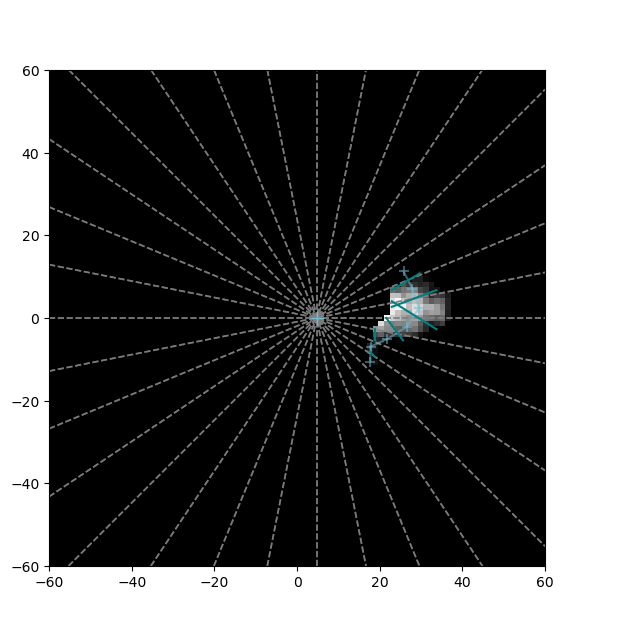

In [270]:
current_rotation = 0

# 
for file in sorted(mf_catalogs_path.iterdir()):
    if file.is_file():

        print(f'{file.name}')

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        # load the matched-filter detection output fits file
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        image_data = np.squeeze(hdul[0].data)

        # extract the area_of_interest
        image_data[~area_of_interest[current_rotation, :, :]] = np.nan

        # access centers calculated by the 2D exponential fit algorithm
        x_center, y_center = centers(f'{file.name}', galaxy_name)

        # plot the bins (only for visual help)
        max_length = 89
        n_bins = 32  
        angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)
        
        fig, ax = plt.subplots(figsize=(8, 8))

        for angle in angles:
            if np.isclose(angle, np.pi/2) or np.isclose(angle, 3*np.pi/2):
                ax.axvline(x=x_center, color='gray', linestyle='--', linewidth=1.2, alpha=0.8)
            else:
                slope = np.tan(angle)
                ax.axline(
                    (x_center, y_center), 
                    slope=slope, 
                    color='gray', 
                    linestyle='--', 
                    linewidth=1.2, 
                    alpha=0.8
                )
        
        ax.plot(x_center, y_center, color='#72BCD4', marker='+', markersize=10, label='Center')

        # identify outliers
        outliers = find_large_outliers(np.unique(image_data))
        outlier_mask = np.isin(image_data, outliers)
        image_data[outlier_mask] = np.nan

        # identify coordinates of interest
        x_of_interest = []
        y_of_interest = []
        val_of_interest = []

        for r_idx, row in enumerate(image_data):
            for c_idx, val in enumerate(row):
                if ~np.isnan(val):
                    val_of_interest.append(val)
                    # scale the data size (89x89) to the plot size (120x120) 
                    scaled_r = -60 + (r_idx * (120 / 89)) #- 120/178
                    scaled_c = -60 + (c_idx * (120 / 89)) #- 120/178
                    x_of_interest.append(scaled_c) # try switching columns and rows
                    y_of_interest.append(scaled_r)
        
        # number of pixels of interest
        n_of_interest = len(x_of_interest)
        
        # calculate the average readius of each bin
        avg_radii = radius_calc(n_of_interest, n_bins, x_center, y_center, x_of_interest, y_of_interest)

        # plot points for the average radius at the angular midpoint of each bin
        angles = np.linspace(0, 2*np.pi, n_bins, endpoint=False)
        angles = (angles + bin_size / 2)

        x_ang = avg_radii * np.cos(angles) + x_center
        y_ang = -avg_radii * np.sin(angles) + y_center

        cmap = plt.cm.gray.copy() # brighter areas represent higher star density
        cmap.set_bad(color='black')

        # set value scale AFTER the center is removed
        min_obj = np.nanmin(image_data)
        max_obj = np.nanmax(image_data)

        plt.scatter(x_ang, y_ang, color='#72BCD4', marker='+', s=50, alpha=0.5)

        # calculate stream length
        total_dist = length_calc(n_bins, x_center, y_center, x_ang, y_ang)

        # calculate stream width
        stream_width_counter, stream_width_total = width_calc(image_data, n_bins, x_ang, y_ang)

        # calculate average stream width
        if stream_width_counter != 0:
            avg_width = stream_width_total/stream_width_counter
            ratio = total_dist/avg_width
        else:
            avg_width = np.nan
            ratio = np.nan
        print(f"Average Width: {avg_width}")
        print(f"Total Distance: {total_dist}")
        print(f"Length/Width Ratio: {ratio}")

        # plot the image with lengths and widths
        current_cmap = copy.copy(mpl.colormaps['gray'])
        current_cmap.set_bad(color='black')
        
        plt.imshow(image_data, extent=[-60,60,-60,60], cmap = current_cmap)

        length_array.append(total_dist)
        width_array.append(avg_width)
        ratio_array.append(ratio)
    
        cbar = plt.colorbar(orientation='vertical')
        if cbar.solids is not None:
            cbar.solids.set_alpha(0)
        if hasattr(cbar, 'lines') and isinstance(cbar.lines, list):
            for line in cbar.lines:
                line.set_alpha(0)
        cbar.outline.set_alpha(0)
        cbar.ax.tick_params(axis='both', colors=(0,0,0,0), labelcolor=(0,0,0,0))

        stfit_path = path(f'/home/giantsid/MAP/stream_analysis/stfit_outputs/{galaxy_name}/fitted/stfit_{galaxy_name}_fitted_d={d}_a={a}_pix={numpix}.png')
        stfit_path.parent.mkdir(parents=True, exist_ok=True)
        plt.gca().invert_yaxis
        plt.savefig(stfit_path)
        plt.show()
        hdul.close()

        current_rotation = current_rotation + 1

In [271]:
def fibonacci_angler(n):
    """ Calculates n equally-spaced angles around a sphere.

    Args:
        n (int):
            The desired number of angles.

    Returns:
        declination_array (array of floats):
            The declinations of the calculated angles.
        azimuthal_array (array of floats):
            The azimuthals of the calculated angles.
    """
    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/((n-1)) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    return declination_array, azimuthal_array

declination_array, azimuthal_array = fibonacci_angler(numangles)

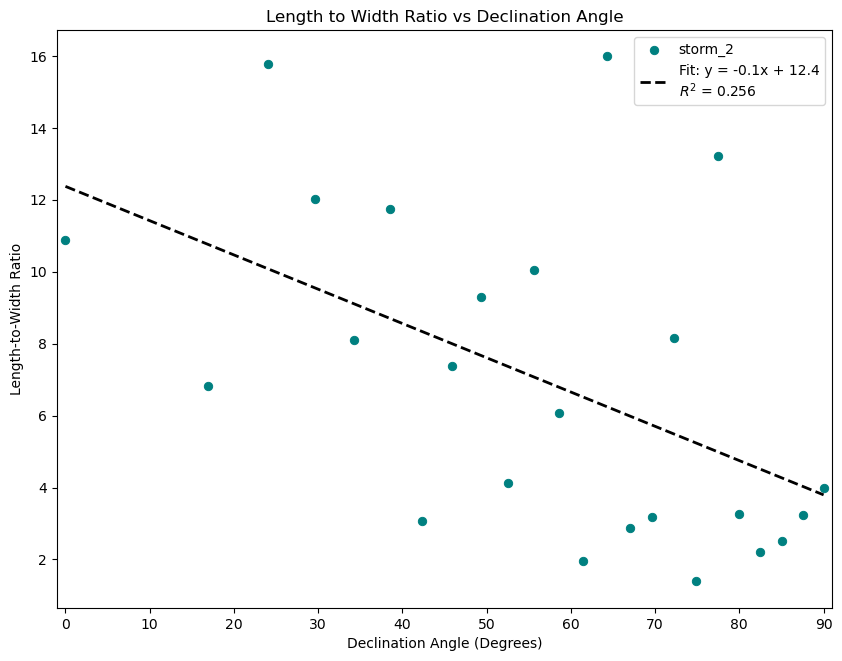

y= -0.09530805027574324 x + 12.374031443144235 , R^2= 0.25600001680619067


In [272]:
# Plot and save the length-to-width ratio vs. declination graph

x = declination_array * 180 / (np.pi)
y = ratio_array

m, b = np.polyfit(x, y, deg=1)
y_pred = m * x + b

r_matrix = np.corrcoef(x, y)
r_value = r_matrix[0, 1]
r_squared = r_value ** 2

fig, ax = plt.subplots(figsize=(10, 7.5))

ax.scatter(x, y, color='teal', linewidth=0.7, label=f'{galaxy_name}')
ax.plot(x, y_pred, color='black', linestyle='--', linewidth=2, \
        label=f'Fit: y = {m:.1f}x + {b:.1f}\n$R^2$ = {r_squared:.3f}')
ax.set_xlim(left=-1, right=91)

ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

ax.set_xlabel("Declination Angle (Degrees)")
ax.set_ylabel("Length-to-Width Ratio")
ax.set_title("Length to Width Ratio vs Declination Angle")

ax.legend()

ratio_v_angle_path=path(f'/home/giantsid/MAP/stream_analysis/stfit_outputs/{galaxy_name}')
ratio_v_angle_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(f'{ratio_v_angle_path}/lw_vs_dec.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print('y=', m, 'x +', b, ', R^2=', r_squared)

In [275]:
# Define the path to save the length, width and their ratio for every angle
lw_path=path(f'/home/giantsid/MAP/stream_analysis/stfit_outputs/{galaxy_name}/lw.txt')
lw_path.parent.mkdir(parents=True, exist_ok=True)

In [276]:
# Save the length, width and their ratio for every angle
if os.path.exists(lw_path):
    os.remove(lw_path)

for i in range(len(ratio_array)):
    with open(f'{lw_path}', 'a') as file:   
        file.write('center of ' f'{galaxy_name}' ' at d=' f'{x[i]:.1f}' ': length=' f'{length_array[i]}' ', width=' f'{width_array[i]}' ', length-to-width ratio=' f'{ratio_array[i]}' '\n')